In [14]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(tmbstan)
library(devtools)


Loading required package: usethis



In [22]:
load_all("../../../hmmTMB")


ℹ Loading hmmTMB


In [23]:
set.seed(123)
# Simulate covariate data -------------------------------------------------
n <- 250
x1 <- scale(rnorm(n))[, 1]          # informative
x2 <- scale(runif(n, -1, 1))[, 1]   # informative
x3 <- scale(rnorm(n))[, 1]          # noise
x4 <- scale(runif(n, -1, 1))[, 1]   # noise

# Hidden state process with two states
trans_mat <- matrix(c(0.95, 0.05,
                      0.05, 0.95),
                    nrow = 2, byrow = TRUE)
state <- numeric(n)
state[1] <- sample(1:2, 1)
for (t in 2:n) {
  state[t] <- sample(1:2, size = 1, prob = trans_mat[state[t - 1], ])
}

# Observation model: only x1 and x2 influence the mean
mu1 <- -0.5 + 1.3 * x1 - 1.5 * x2
mu2 <- 0.5 - 1.2 * x1 + 1.6 * x2
sigma <- c(0.4, 0.6)

obs_mean <- ifelse(state == 1, mu1, mu2)
obs_sd <- sigma[state]
y <- rnorm(n, mean = obs_mean, sd = obs_sd)

dat <- data.frame(
  ID = factor(1),
  y = y,
  x1 = as.numeric(x1),
  x2 = as.numeric(x2),
  x3 = as.numeric(x3),
  x4 = as.numeric(x4)
)

head(dat, 3)

,ID,y,x1,x2,x3,x4
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.3245394,-0.5858349,-0.5372243,-0.5812190,1.12419123
2,1,0.4706628,-0.2352372,-0.4938639,-1.0004093,0.02837603
3,1,-1.6093793,1.6635904,-0.7618941,0.1741647,0.22607596


In [24]:
# Helper to build observation models -------------------------------------
create_observation <- function(data, horseshoe) {
  formulas <- list(y = list(mean = ~ x1 + x2 + x3 + x4, sd = ~ 1))
  par0 <- list(y = list(mean = c(mean(data$y) - 0.5, mean(data$y) + 0.5),
                        sd = c(sd(data$y), sd(data$y))))
  obs <- hmmTMB::Observation$new(
    data = data,
    dists = list(y = "norm"),
    n_states = 2,
    par = par0,
    formulas = formulas,
    horseshoe = horseshoe
  )
  obs$update_par(par = obs$suggest_initial())
  obs
}

obs_hs <- create_observation(dat, horseshoe = TRUE)
obs_no_hs <- create_observation(dat, horseshoe = FALSE)

# Hidden process (no covariates) -----------------------------------------
create_hidden <- function(data) {
  hmmTMB::MarkovChain$new(data = data, n_states = 2)
}

hid_hs <- create_hidden(dat)
hid_no_hs <- create_hidden(dat)

In [25]:
# Build HMM objects -------------------------------------------------------
model_hs <- hmmTMB::HMM$new(obs = obs_hs, hid = hid_hs)
model_no_hs <- hmmTMB::HMM$new(obs = obs_no_hs, hid = hid_no_hs)

In [26]:
message("Fitting horseshoe prior model ...")
# model_hs$fit_stan(iter = 5000, warmup = 1000, chains = 1, refresh = 0)
model_hs$fit(silent=TRUE)


Fitting horseshoe prior model ...



ERROR: Error in self$setup(silent = silent): Log-likelihood is NaN or infinite at starting parameters. Check that the data are within the domain of definition of the observation distributions, or try other starting parameters.


In [20]:
message("Fitting non-horseshoe model ...")
#model_no_hs$fit_stan(iter = 5000, warmup = 1000, chains = 1, refresh = 0)
model_no_hs$fit(silent=TRUE)

Fitting non-horseshoe model ...



In [21]:
# With random effects
model_hs$obs()$coeff_fe()

y.mean.state1.(Intercept),4.891537e-01
y.mean.state1.x1,-1.224441e+00
y.mean.state1.x2,1.539207e+00
y.mean.state1.x3,1.233750e-09
y.mean.state1.x4,-4.044258e-13
y.mean.state2.(Intercept),-4.741561e-01
y.mean.state2.x1,1.397174e+00
y.mean.state2.x2,-1.460358e+00
y.mean.state2.x3,1.660135e-08
y.mean.state2.x4,-3.460686e-13
y.sd.state1.(Intercept),-5.019916e-01


In [ ]:
# With Fixed effects
model_hs$obs()$coeff_fe()

y.mean.state1.(Intercept),4.891537e-01
y.mean.state1.x1,-1.224441e+00
y.mean.state1.x2,1.539207e+00
y.mean.state1.x3,1.233750e-09
y.mean.state1.x4,-4.044258e-13
y.mean.state2.(Intercept),-4.741561e-01
y.mean.state2.x1,1.397174e+00
y.mean.state2.x2,-1.460358e+00
y.mean.state2.x3,1.660135e-08
y.mean.state2.x4,-3.460686e-13
y.sd.state1.(Intercept),-5.019916e-01


In [ ]:
# With random effects
model_no_hs$obs()$coeff_fe()

In [ ]:
# With fixes effects
model_no_hs$obs()$coeff_fe()

y.mean.state1.(Intercept),0.509897900
y.mean.state1.x1,-1.194756000
y.mean.state1.x2,1.583530119
y.mean.state1.x3,0.029542718
y.mean.state1.x4,-0.006903575
y.mean.state2.(Intercept),-0.464350282
y.mean.state2.x1,1.384443029
y.mean.state2.x2,-1.471545021
y.mean.state2.x3,-0.051608554
y.mean.state2.x4,0.003628362
y.sd.state1.(Intercept),-0.491478797


In [ ]:
model_no_hs$out_stan()

Inference for Stan model: hmmTMB.
1 chains, each with iter=5000; warmup=1000; thin=1; 
post-warmup draws per chain=4000, total post-warmup draws=4000.

                          mean     se_mean           sd          2.5%
coeff_fe_obs[1]           0.51 0.00000e+00         0.05  4.100000e-01
coeff_fe_obs[2]          -1.20 0.00000e+00         0.05 -1.280000e+00
coeff_fe_obs[3]           1.58 0.00000e+00         0.05  1.490000e+00
coeff_fe_obs[4]           0.03 0.00000e+00         0.05 -7.000000e-02
coeff_fe_obs[5]          -0.01 0.00000e+00         0.05 -1.000000e-01
coeff_fe_obs[6]          -0.45 0.00000e+00         0.05 -5.500000e-01
coeff_fe_obs[7]           1.37 0.00000e+00         0.05  1.270000e+00
coeff_fe_obs[8]          -1.48 0.00000e+00         0.05 -1.580000e+00
coeff_fe_obs[9]          -0.06 0.00000e+00         0.04 -1.500000e-01
coeff_fe_obs[10]          0.01 0.00000e+00         0.05 -8.000000e-02
coeff_fe_obs[11]         -0.47 0.00000e+00         0.05 -5.700000e-01
coeff_fe

In [ ]:
model_hs$out_stan()

ERROR: Error in model_hs$out_stan(): Run fit_stan() first


In [ ]:
rstan::stan_dens(model_hs$out_stan())

ERROR: Error in model_hs$out_stan(): Run fit_stan() first


'pars' not specified. Showing first 10 parameters by default.



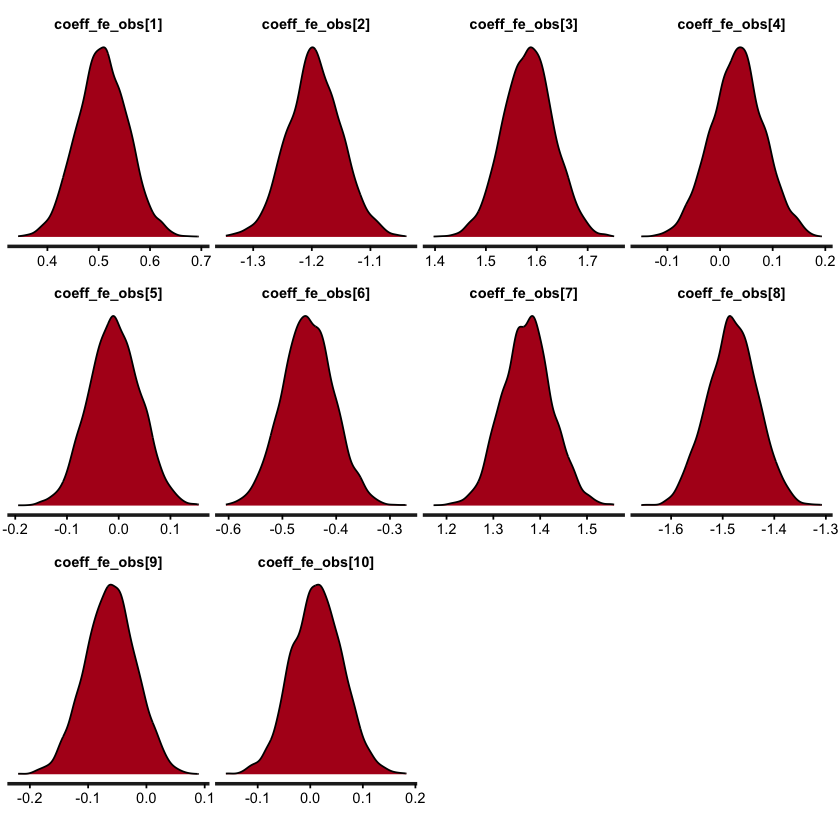

In [ ]:
rstan::stan_dens(model_no_hs$out_stan())

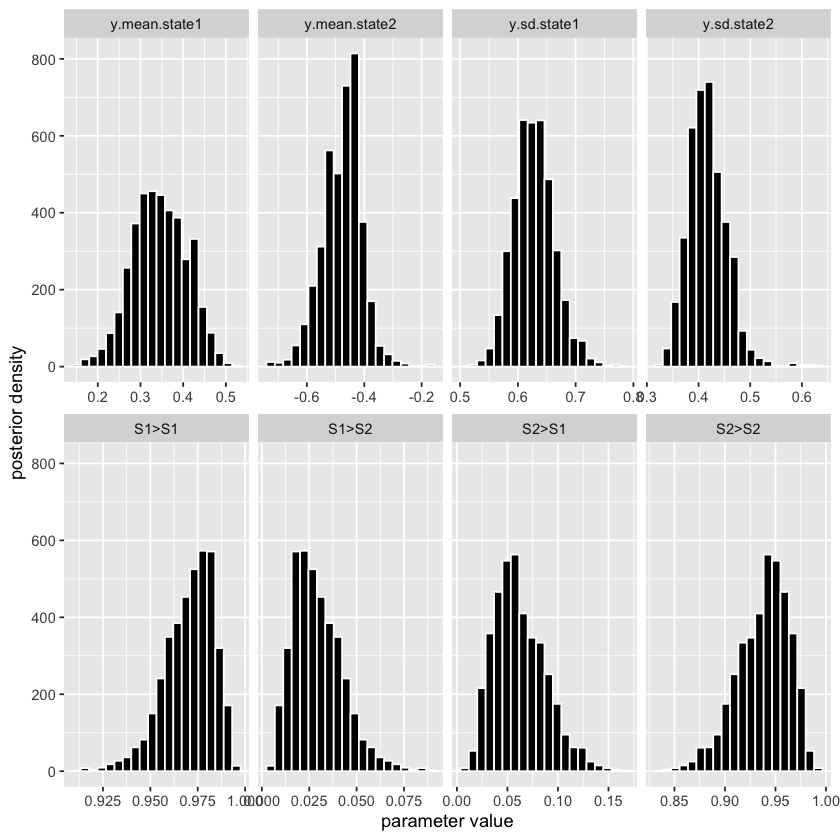

In [ ]:
iters_df <- as.data.frame.table(model_hs$iters())
ggplot(iters_df, aes(x = Freq)) +
  geom_histogram(bins = 20, fill = "black", col = "white") +
  facet_wrap("Var2", nrow = 2, scales = "free_x") +
  labs(x = "parameter value", y = "posterior density")

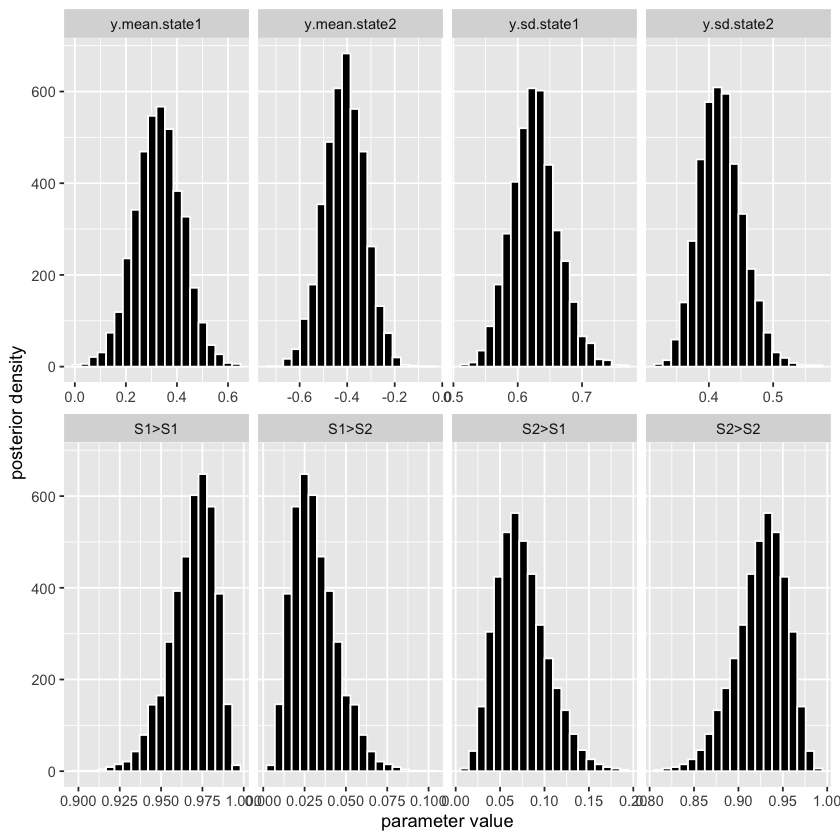

In [ ]:
iters_df <- as.data.frame.table(model_no_hs$iters())
ggplot(iters_df, aes(x = Freq)) +
  geom_histogram(bins = 20, fill = "black", col = "white") +
  facet_wrap("Var2", nrow = 2, scales = "free_x") +
  labs(x = "parameter value", y = "posterior density")